In [ ]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
import matplotlib.ticker as ticker
from escripts import estats
import matplotlib.pyplot as plt
plt.style.use('/Users/eb35267/Desktop/code/mpl_style/pres_style.mplstyle')

In [13]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels, include_zs = [11])
compressed_data = edata.reduce(sorted_data)

Skipping $z = 9.0
Skipping $z = 10.0
Skipping $z = 12.5
Skipping $z = 13.5
Skipping $z = 14.5


In [14]:
params = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 'dbetadz': 
                                 {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 'dlogMcdz':{'fit':False, 'value':0}})

In [15]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [16]:
low_z_fit = [0.67, -1.2, 12.11, -0.82, 0.03, 0.31]

Text(0.5, 1.0, '$z\\simeq11$')

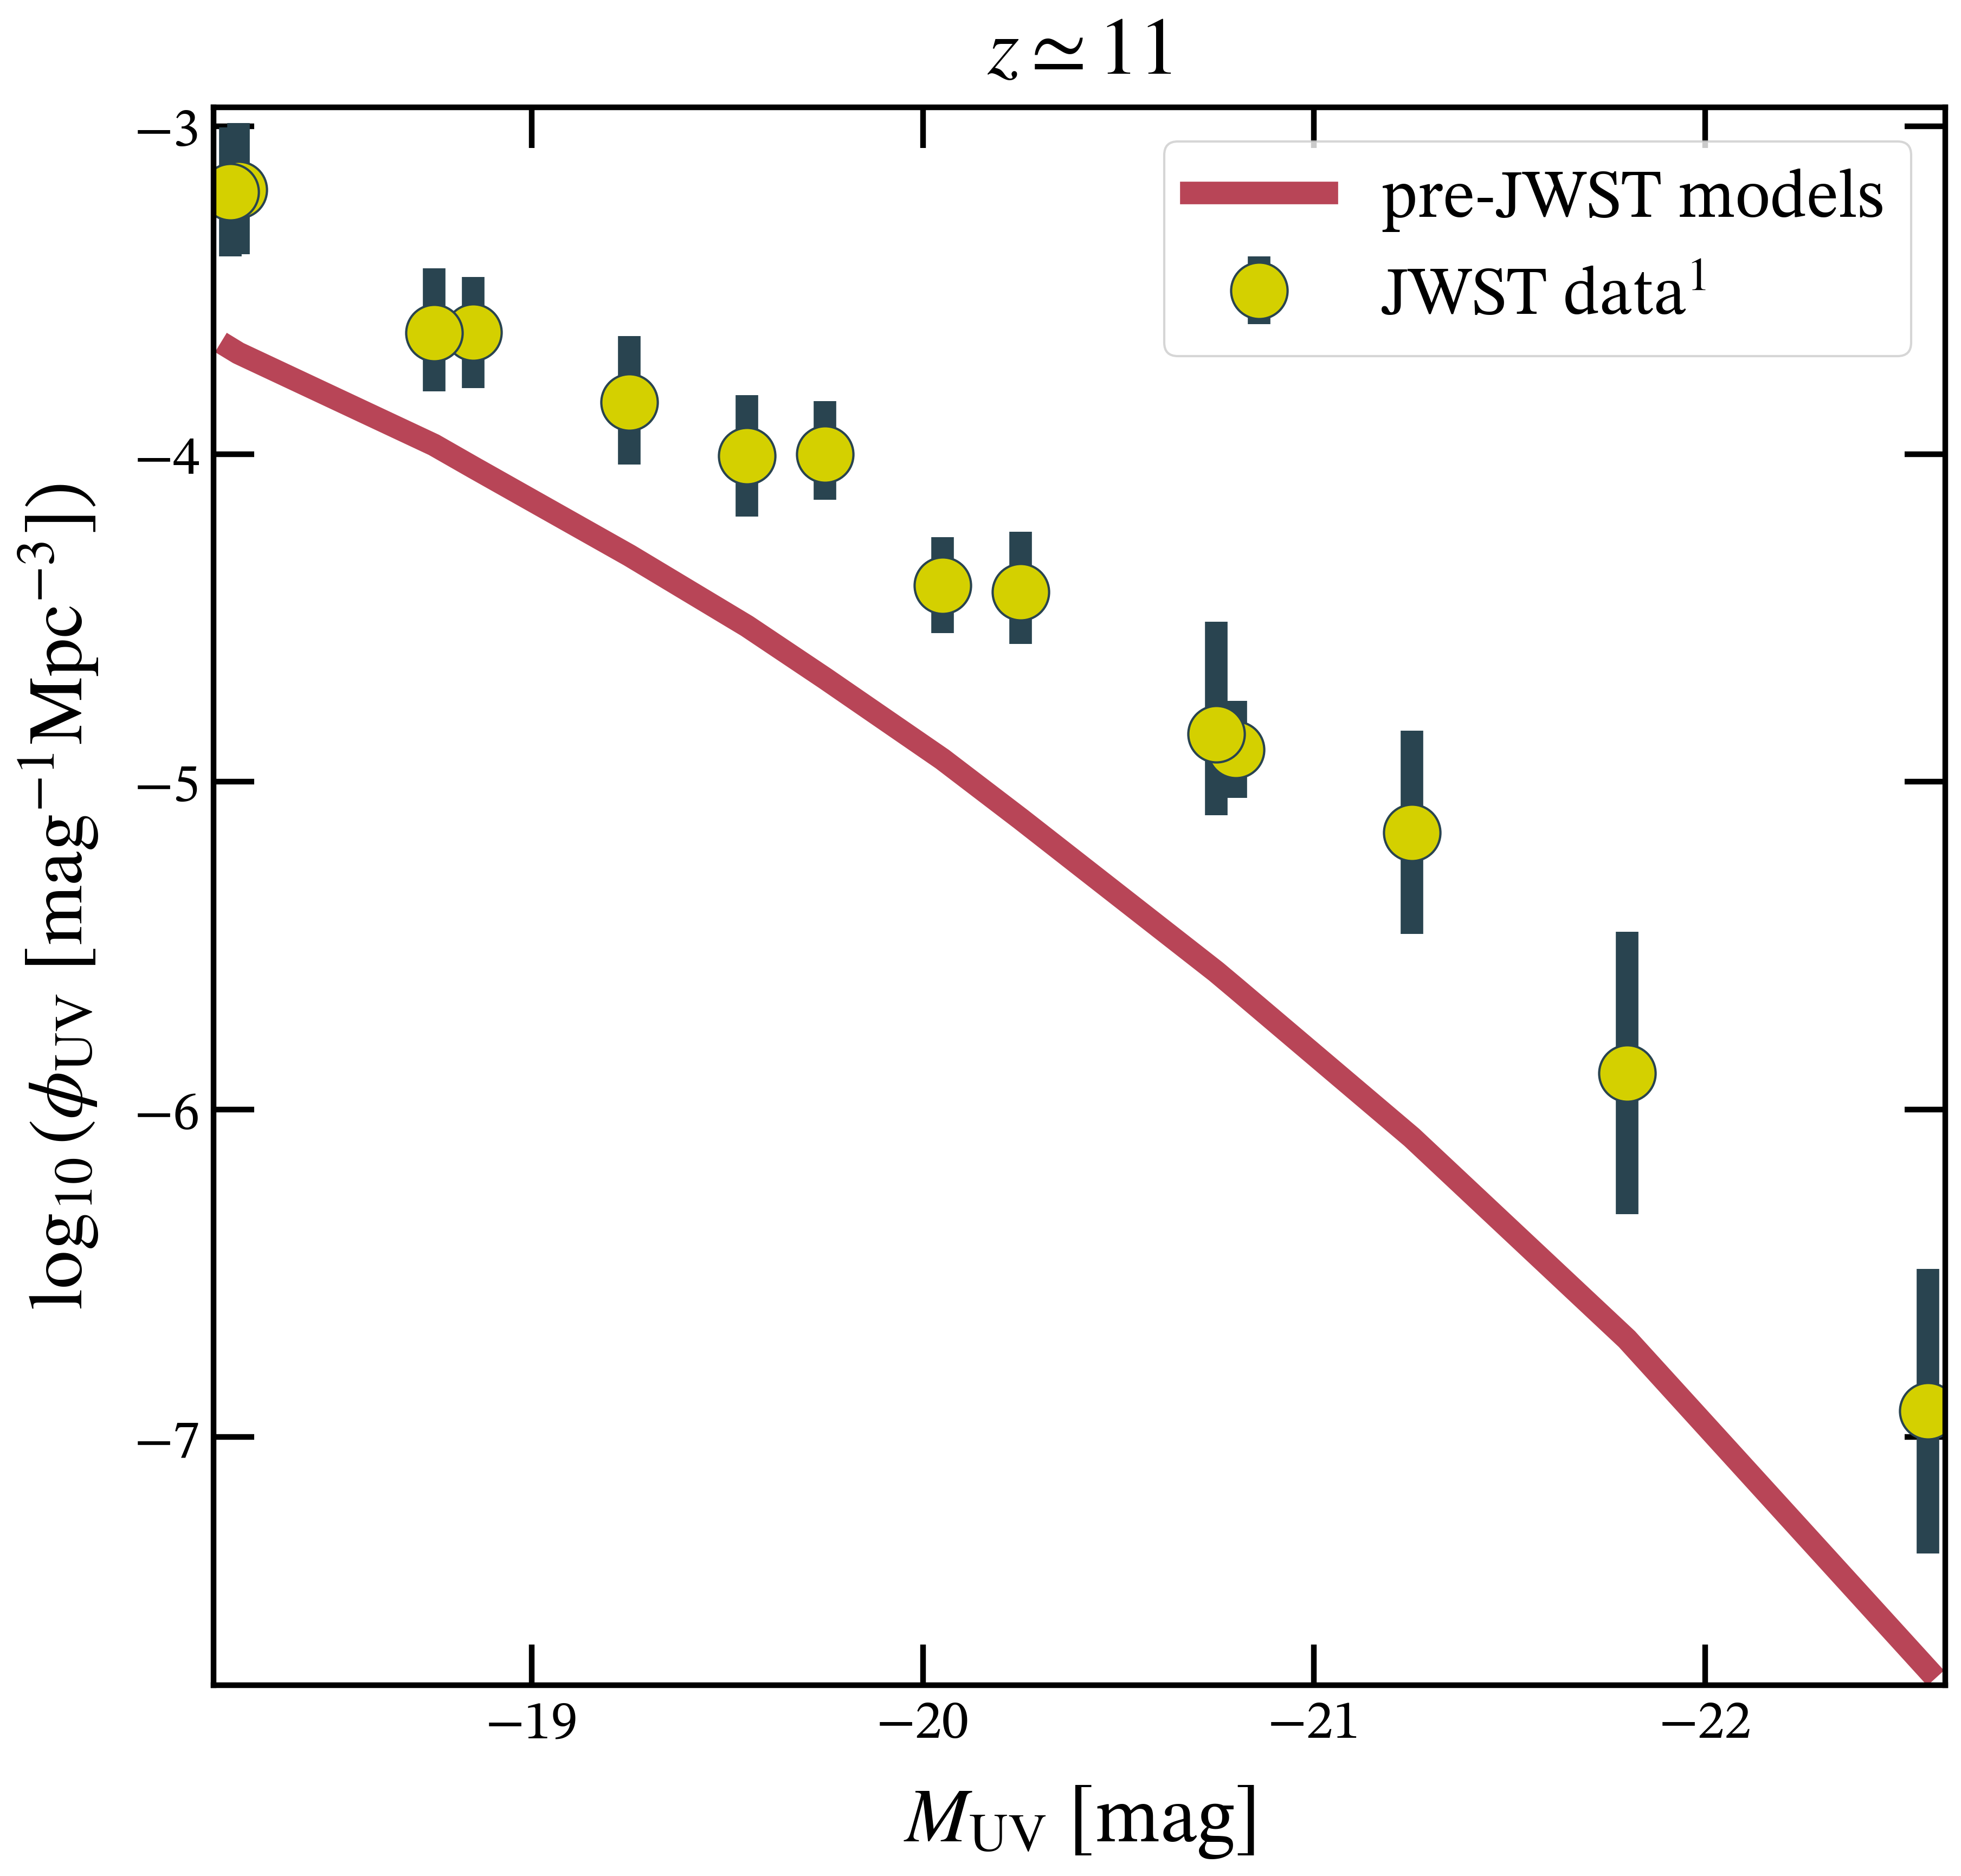

In [ ]:
plt.style.reload_library()
plt.style.use('/Users/eb35267/Desktop/code/mpl_style/pres_style.mplstyle')

fig, ax = plt.subplots()
multiple = 3
fig.set_size_inches(multiple*4.58, multiple*4.2)
plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5]
zdat, zerr = compressed_data[0][0], compressed_data[0][1]
ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat, zerr, plot_xdat, plot_xerr, low_z_fit)), label = fr'pre-JWST models')
ax.invert_xaxis()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = compressed_data[0]
yerr_lower, yerr_upper = estats.calc_log_error(ydat, yerr_lower), estats.calc_log_error(ydat, yerr_upper)
ax.errorbar(xdat, np.log10(ydat), [yerr_lower, yerr_upper], capsize=0, label = 'JWST data$^1$', markeredgecolor = eplots.navy, fmt = 'o',
            markerfacecolor = eplots.yellow, ecolor = eplots.navy)

ax.legend()
ax.set_title(r'$z\simeq11$')